# Bayesian BLP: Structural Demand Estimation on Aggregate Market Shares


## When to use this model

PyMC-Marketing ships three discrete-choice model families. Choosing the right one
avoids both under-fitting and unnecessary complexity:

| Model | Data shape | What it answers |
|---|---|---|
| **MNL / MixedLogit** | Individual choice occasions | Who chose what, and why? |
| **MVITS** | Aggregate share time series | What happened when brand X launched? |
| **BayesianBLP** *(this notebook)* | Aggregate share panels (e.g. Nielsen/IRI scanner) | What would happen if I changed price? |

**BayesianBLP** is a *structural* random-coefficients logit on aggregate shares — the
Bayesian reformulation of Berry, Levinsohn & Pakes (1995) following Jiang, Manchanda
& Rossi (2009). It is the right tool when:

- You only have **aggregate market shares** (not individual transactions).
- You need structurally grounded **cross-price substitution patterns**.
- Prices may be **endogenous** (set by firms who observe unobserved demand shocks)
  and you have **cost or rival-characteristic instruments** to correct for the bias.
- You want **full posterior uncertainty** on elasticities and counterfactual shares,
  with correct propagation through the structural demand model.

The Bayesian formulation replaces the classical BLP contraction mapping + GMM with a
joint posterior over preference parameters and the latent demand shocks ξ_jt. This
makes hierarchical pooling across regions cheap and returns honest credible intervals
even under weak instruments.


In [1]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np

from pymc_marketing.customer_choice import BayesianBLP, generate_blp_panel

warnings.filterwarnings("ignore")
az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 5]
plt.rcParams["figure.dpi"] = 100
%config InlineBackend.figure_format = 'retina'

## 1. Synthetic data: a BLP-style aggregate share panel

We use `generate_blp_panel` to create a synthetic panel with known true parameters.
The data-generating process produces a joint `(η_jt, ξ̃_jt)` shock so that prices
are **endogenous** — naive estimation without instruments will bias the price
coefficient toward zero.

The returned DataFrame is in long format: one row per (market, product), with the
outside good as a special row labelled `'outside'`. The `truth` dictionary records
the DGP parameters we will try to recover.


In [2]:
df, truth = generate_blp_panel(
    T=40,  # markets (think: 40 weeks)
    J=3,  # inside products
    K=2,  # product characteristics
    L=2,  # instruments per product
    true_alpha=-2.0,
    true_beta=np.array([0.8, 1.2]),
    sigma_alpha=0.5,  # std of consumer price heterogeneity
    instrument_strength=0.7,  # first-stage R² ≈ 0.49
    price_xi_corr=0.6,  # endogeneity severity
    market_size=4_000,
    n_dgp_draws=3_000,
    random_seed=42,
    return_truth=True,
)

print(
    f"Panel: {df['market'].nunique()} markets × {len(truth['characteristic_cols'])} "
    f"characteristics + {len(truth['instrument_cols'])} instruments"
)
print(f"True alpha (price):  {truth['alpha']:.3f}")
print(f"True beta:           {truth['beta']}")
print(f"True sigma_alpha:    {truth['sigma_alpha']:.3f}")
print(f"Outside share mean:  {df[df['product'] == 'outside']['share'].mean():.3f}")

Panel: 40 markets × 2 characteristics + 2 instruments
True alpha (price):  -2.000
True beta:           [0.8 1.2]
True sigma_alpha:    0.500
Outside share mean:  0.667


In [3]:
df.head(8)

,region,market,product,share,n,price,x_0,x_1,z_0,z_1
0,r0,0,outside,0.9315,4000,0.000000,0.0,0.000000,0.000000,0.000000
1,r0,0,prod_0,0.0005,4000,4.124200,0.0,-0.863345,0.006339,2.597674
2,r0,0,prod_1,0.0380,4000,1.210960,0.0,-0.147529,0.223080,1.433215
3,r0,0,prod_2,0.0300,4000,1.987674,0.0,-0.152523,0.091520,0.580777
4,r0,1,outside,0.5560,4000,0.000000,0.0,0.000000,0.000000,0.000000
5,r0,1,prod_0,0.3985,4000,0.929217,1.0,0.383394,-0.056783,-0.170408
6,r0,1,prod_1,0.0445,4000,2.298272,1.0,0.999824,-0.779482,0.430301
7,r0,1,prod_2,0.0010,4000,3.006346,0.0,-1.058536,-0.851537,0.665585


## 2. Model specification and prior predictive check

We instantiate `BayesianBLP` with:
- `random_coef_on=['price']` — consumer-level price heterogeneity `α_i = α_r + σ_α · ν_i`
- `instruments=truth['instrument_cols']` — enables the price-endogeneity correction
- `n_mc_draws=100` — Owen-scrambled Halton draws for the share integral (use ≥ 200 in practice)

A prior predictive check confirms that the priors put mass on shares that are
plausible for scanner data (no pathological predictions).


In [4]:
model = BayesianBLP(
    market_data=df,
    characteristics=truth["characteristic_cols"],
    instruments=truth["instrument_cols"],
    random_coef_on=["price"],
    n_mc_draws=100,
    random_seed=0,
)
model

Sampling: [alpha, beta, log_share_ratio, pi_0, pi_z, price_obs, rho_price_xi, sigma_eta, sigma_random, sigma_xi, sigma_xi_j, xi_j_raw, xi_tilde_raw]


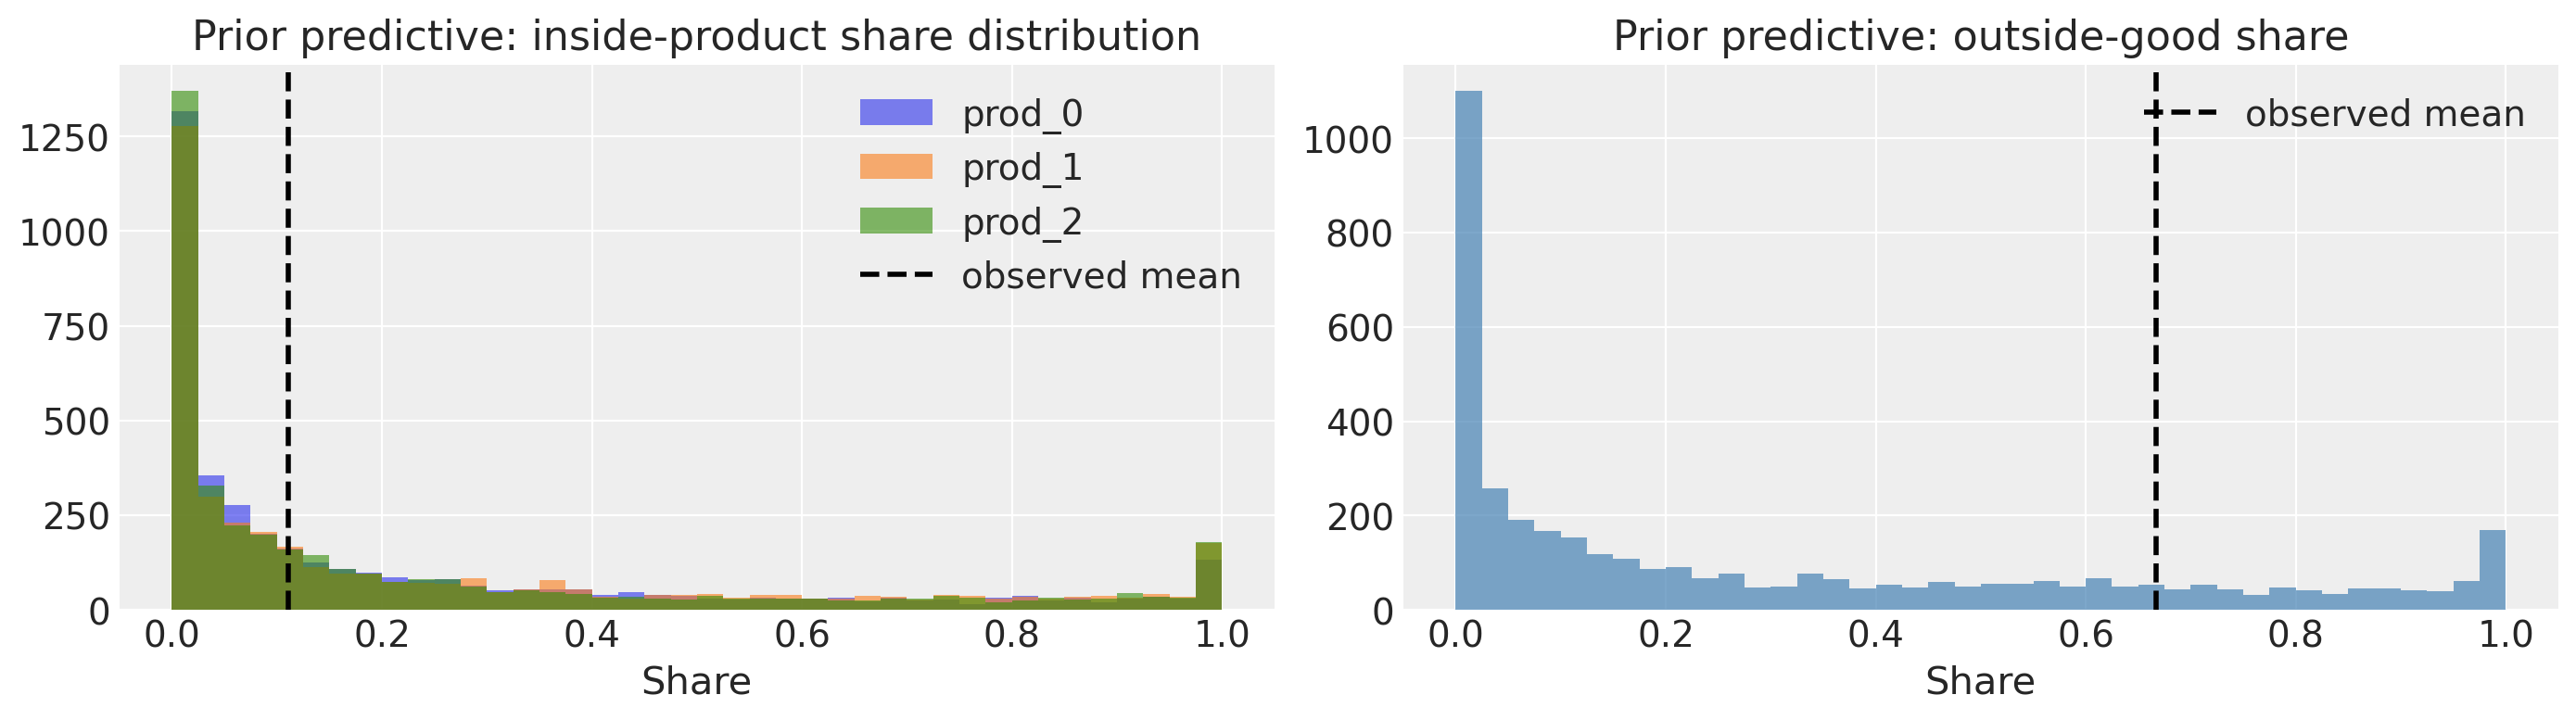

Shares sum to 1: True


In [5]:
prior = model.sample_prior_predictive(samples=100)

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

# Inside shares
s_in_prior = prior.prior["s_inside"].values.reshape(-1, model._M, model._J)
for j, pname in enumerate(model._inside_products):
    axs[0].hist(s_in_prior[:, :, j].ravel(), bins=40, alpha=0.6, label=pname)
axs[0].axvline(
    df[df["product"] != "outside"].groupby("product")["share"].mean().mean(),
    color="k",
    lw=2,
    ls="--",
    label="observed mean",
)
axs[0].set_title("Prior predictive: inside-product share distribution")
axs[0].set_xlabel("Share")
axs[0].legend()

# Outside share
s_out_prior = prior.prior["s_outside"].values.ravel()
axs[1].hist(s_out_prior, bins=40, color="steelblue", alpha=0.7)
axs[1].axvline(
    df[df["product"] == "outside"]["share"].mean(),
    color="k",
    lw=2,
    ls="--",
    label="observed mean",
)
axs[1].set_title("Prior predictive: outside-good share")
axs[1].set_xlabel("Share")
axs[1].legend()

plt.tight_layout()
plt.show()
print(
    f"Shares sum to 1: "
    f"{np.allclose(s_in_prior.sum(axis=-1) + prior.prior['s_outside'].values[0], 1.0)}"
)

## 3. Fitting the model with instruments

The model is fit with the `numpyro` backend. We use deliberately small draw counts
here for speed — in practice use `draws=2000, tune=2000, chains=4`.

The key sampler settings:
- `nuts_sampler='numpyro'` — JAX-accelerated NUTS, essential for the ξ̃_jt block
- `target_accept=0.95` — the default; the funnel-prone ξ̃ block warrants a high
  acceptance target


In [21]:
_FIT_KWARGS = dict(
    nuts_sampler="nutpie",
    draws=1000,
    tune=1000,
    chains=4,
    progressbar=True,
    random_seed=0,
)

model.fit(**_FIT_KWARGS)
n_div = int(model.idata.sample_stats["diverging"].values.sum())
print(f"Divergences: {n_div}")  # should be 0

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.07,63
,2000,1,0.07,63
,2000,0,0.06,63
,2000,0,0.07,63


Divergences: 1


## 4. Posterior summary and parameter recovery

We check whether the fitted posterior recovers the known DGP parameters.
The key structural parameters are:

- `alpha_r` — the (mean-field) price coefficient; should be negative and close to
  the true value
- `beta_r` — characteristic utility weights; should recover `true_beta`
- `sigma_random` — standard deviation of consumer-level price heterogeneity
- `rho_price_xi` — the endogeneity correlation (how much ξ co-moves with price
  residuals); a positive value confirms that price is endogenous


In [22]:
key_vars = ["alpha_r", "beta_r", "sigma_random", "rho_price_xi"]
az.summary(model.idata, var_names=key_vars, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_r[all],-2.01,0.07,-2.14,-1.90,0.00,0.0,196.61,394.03,1.02
"beta_r[all, x_0]",0.79,0.05,0.70,0.88,0.00,0.0,413.20,865.10,1.01
"beta_r[all, x_1]",1.19,0.03,1.14,1.24,0.00,0.0,300.64,610.34,1.02
sigma_random[price],0.55,0.04,0.47,0.64,0.00,0.0,364.34,820.65,1.01
rho_price_xi,0.58,0.11,0.39,0.77,0.01,0.0,205.24,442.91,1.02


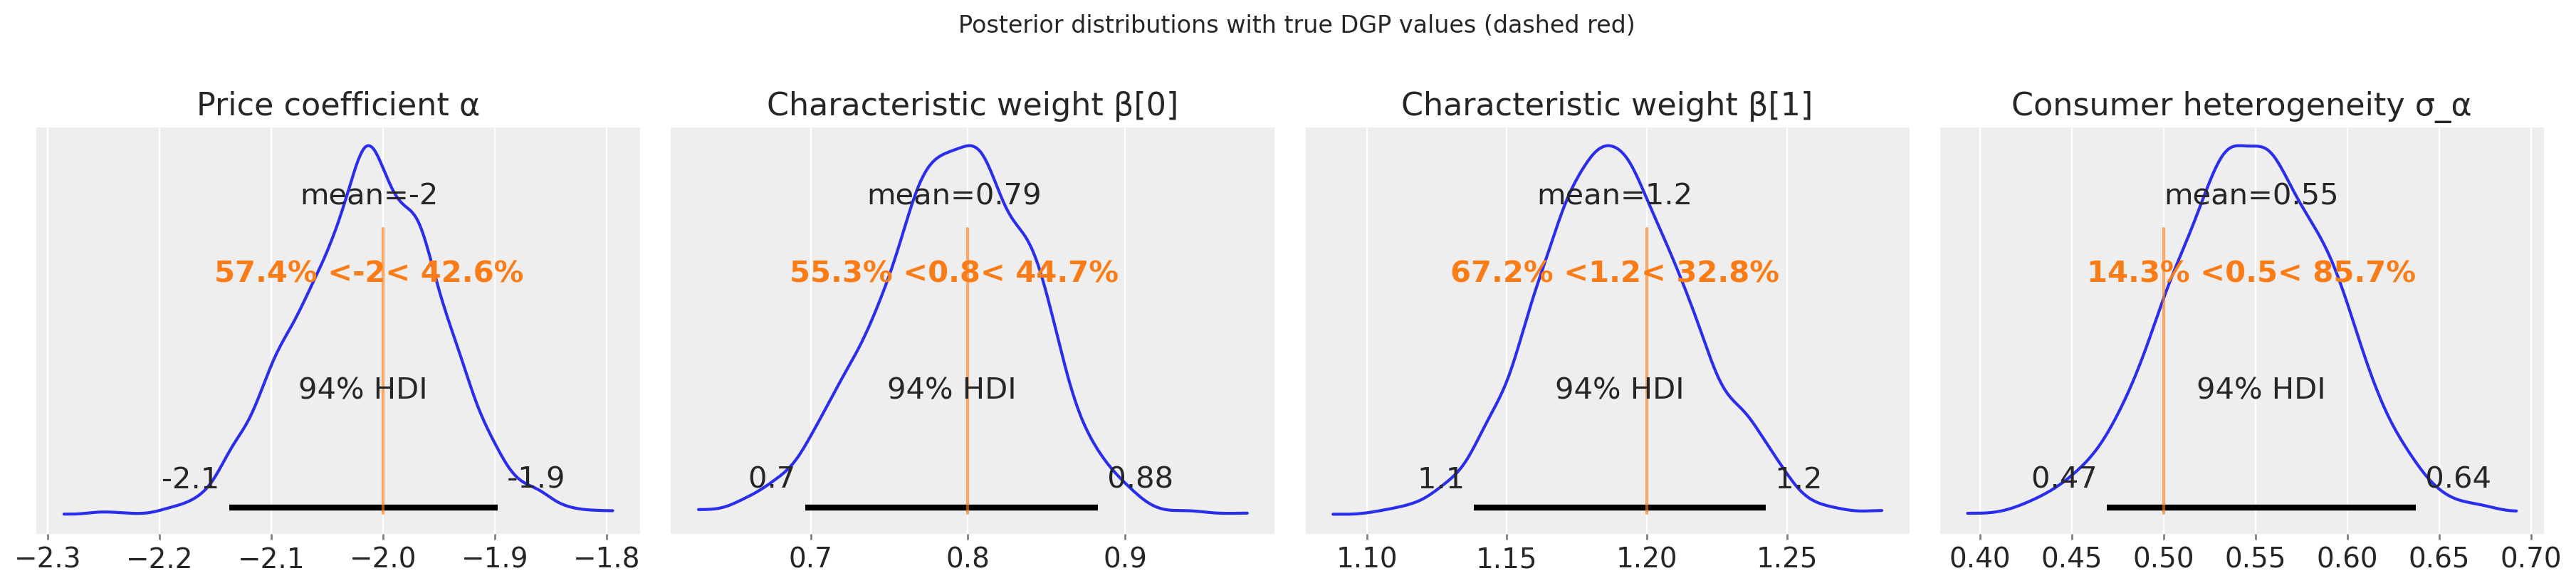

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(18, 4))

truth_vals = {
    "alpha_r": truth["alpha"],
    "beta_r[0]": truth["beta"][0],
    "beta_r[1]": truth["beta"][1],
    "sigma_random[0]": truth["sigma_alpha"],
}

ax = axs[0]
az.plot_posterior(model.idata, var_names=["alpha_r"], ref_val=truth["alpha"], ax=ax)
ax.set_title("Price coefficient α")

beta_post = model.idata.posterior["beta_r"].values.reshape(
    -1, model._J if model.region_col else 1, 2
)
for k, ax in zip(range(2), axs[1:3], strict=True):
    az.plot_posterior(
        model.idata,
        var_names=["beta_r"],
        coords={"characteristic": truth["characteristic_cols"][k]},
        ref_val=float(truth["beta"][k]),
        ax=ax,
    )
    ax.set_title(f"Characteristic weight β[{k}]")

az.plot_posterior(
    model.idata,
    var_names=["sigma_random"],
    coords={"random_coef": "price"},
    ref_val=truth["sigma_alpha"],
    ax=axs[3],
)
axs[3].set_title("Consumer heterogeneity σ_α")

plt.suptitle("Posterior distributions with true DGP values (dashed red)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Endogeneity correction: IV vs. no-IV

The headline feature of BLP is the endogeneity correction. When prices are
set by firms that observe unobserved demand shocks ξ_jt, naively regressing
shares on prices overstates willingness-to-pay (biases α toward zero).

We fit a second model *without* instruments to illustrate the bias. With
`price_xi_corr=0.6`, the no-IV estimator is expected to recover an alpha
substantially less negative than the truth.


In [24]:
# Fit without instruments (endogeneity bias expected)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model_noiv = BayesianBLP(
        market_data=df,
        characteristics=truth["characteristic_cols"],
        instruments=None,  # no IV
        random_coef_on=["price"],
        n_mc_draws=100,
        random_seed=0,
    )
    model_noiv.fit(**_FIT_KWARGS)

iv_alpha = float(model.idata.posterior["alpha_r"].values.mean())
noiv_alpha = float(model_noiv.idata.posterior["alpha_r"].values.mean())

print(f"True alpha:            {truth['alpha']:+.3f}")
print(
    f"IV posterior mean:     {iv_alpha:+.3f}  "
    f"(bias {abs(truth['alpha'] - iv_alpha):.3f})"
)
print(
    f"no-IV posterior mean:  {noiv_alpha:+.3f}  "
    f"(bias {abs(truth['alpha'] - noiv_alpha):.3f})"
)
print()
if abs(truth["alpha"] - noiv_alpha) > abs(truth["alpha"] - iv_alpha):
    print("✓  IV fit is closer to truth, endogeneity correction is working.")
else:
    print("✗  Unexpected — check the seed / DGP.")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,14,0.08,63
,2000,0,0.07,63
,2000,0,0.08,127
,2000,0,0.08,31


True alpha:            -2.000
IV posterior mean:     -2.013  (bias 0.013)
no-IV posterior mean:  -1.910  (bias 0.090)

✓  IV fit is closer to truth, endogeneity correction is working.


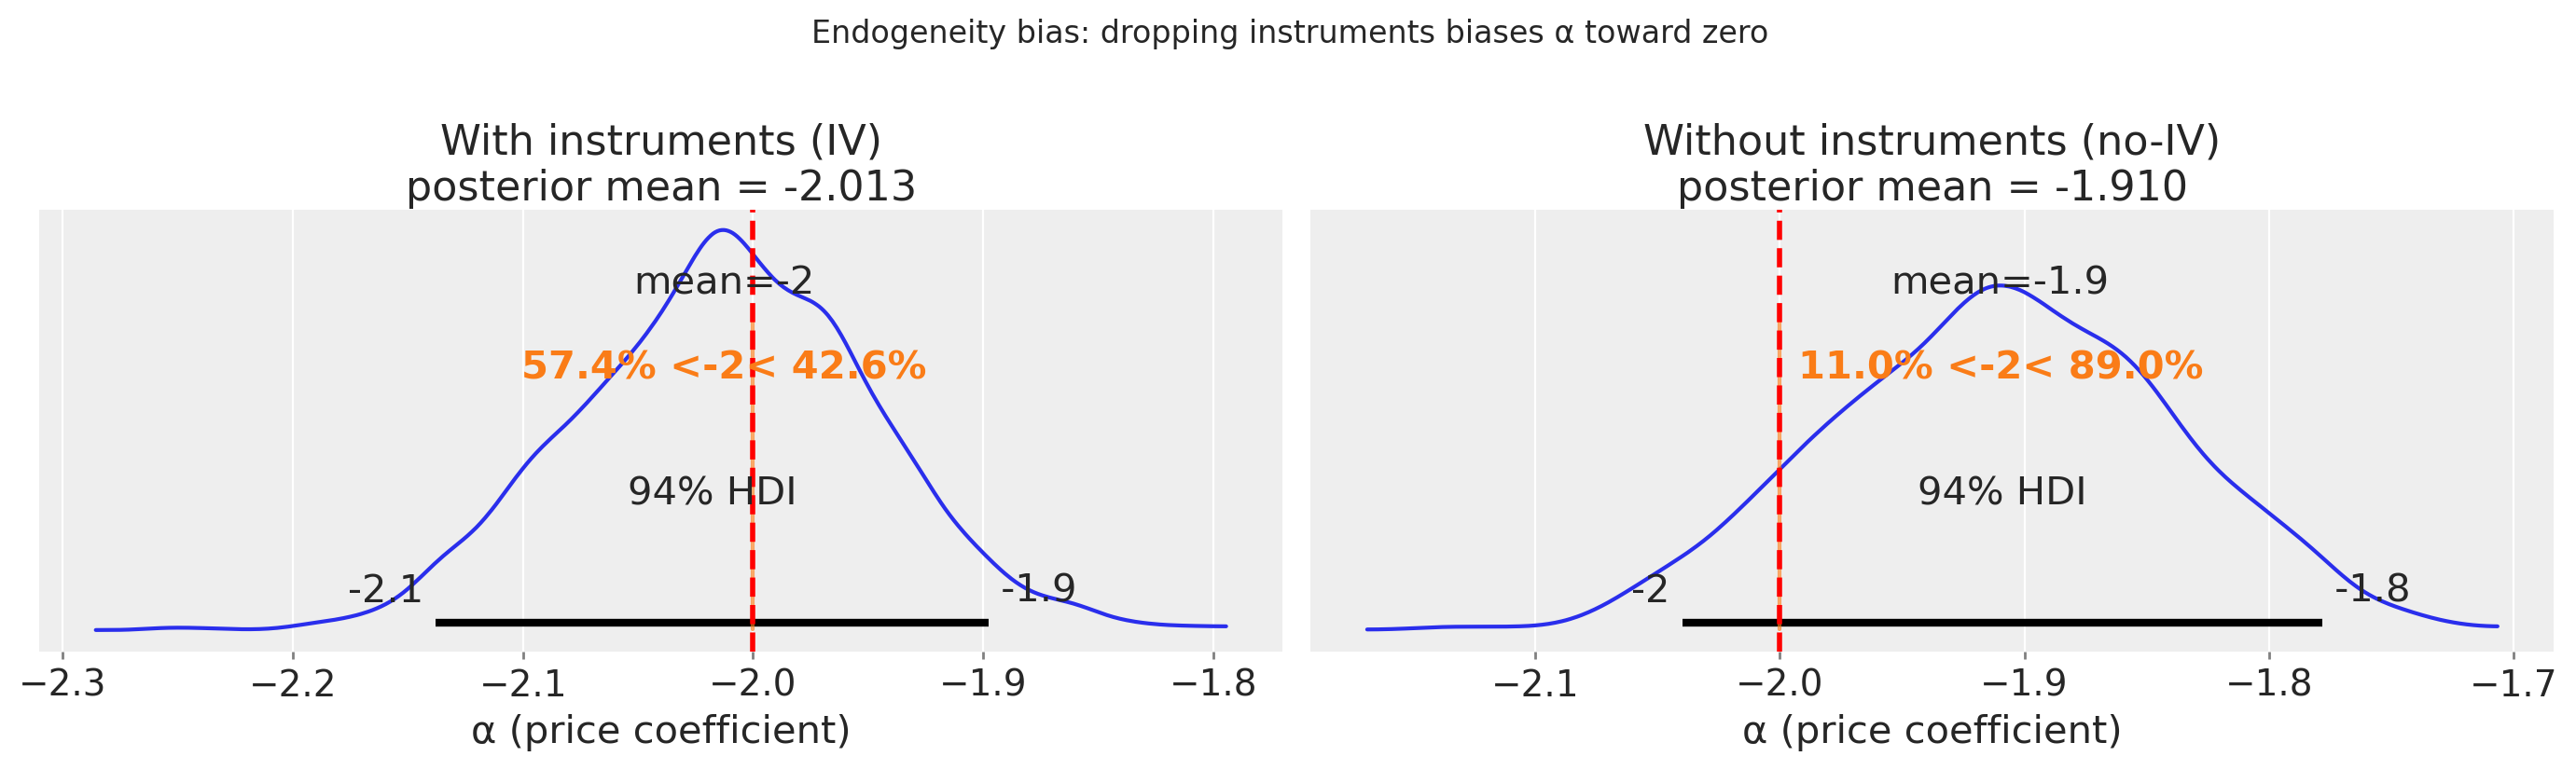

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

az.plot_posterior(
    model.idata,
    var_names=["alpha_r"],
    ref_val=truth["alpha"],
    ax=axs[0],
)
axs[0].set_title(f"With instruments (IV)\nposterior mean = {iv_alpha:.3f}")

az.plot_posterior(
    model_noiv.idata,
    var_names=["alpha_r"],
    ref_val=truth["alpha"],
    ax=axs[1],
)
axs[1].set_title(f"Without instruments (no-IV)\nposterior mean = {noiv_alpha:.3f}")

for ax in axs:
    ax.axvline(truth["alpha"], color="red", lw=2, ls="--", label="truth")
    ax.set_xlabel("α (price coefficient)")

plt.suptitle("Endogeneity bias: dropping instruments biases α toward zero", y=1.02)
plt.tight_layout()
plt.show()

## 6. Price elasticities

The closed-form mixed-logit elasticity is

$$
\varepsilon_{jk}(m) = \frac{p_{km}}{s_{jm}} \cdot \frac{1}{R}
\sum_r \alpha_{ir}(m) \cdot s_{jmr} \bigl(\delta_{jk} - s_{kmr}\bigr)
$$

where the integral over consumer types uses the same Halton draws as the
likelihood (essentially free). Own-price elasticities are on the diagonal
(negative), cross-price elasticities are off-diagonal (positive for
substitutes).

`elasticities(at='mean')` returns the posterior-mean elasticity matrix;
`at='samples'` returns the full posterior distribution.


In [26]:
elast = model.elasticities(at="mean", n_samples=300)
print("Elasticity array shape:", elast.shape)  # (market, share, price)
print("Dims:", elast.dims)

Elasticity array shape: (40, 3, 3)
Dims: ('market', 'share', 'price')


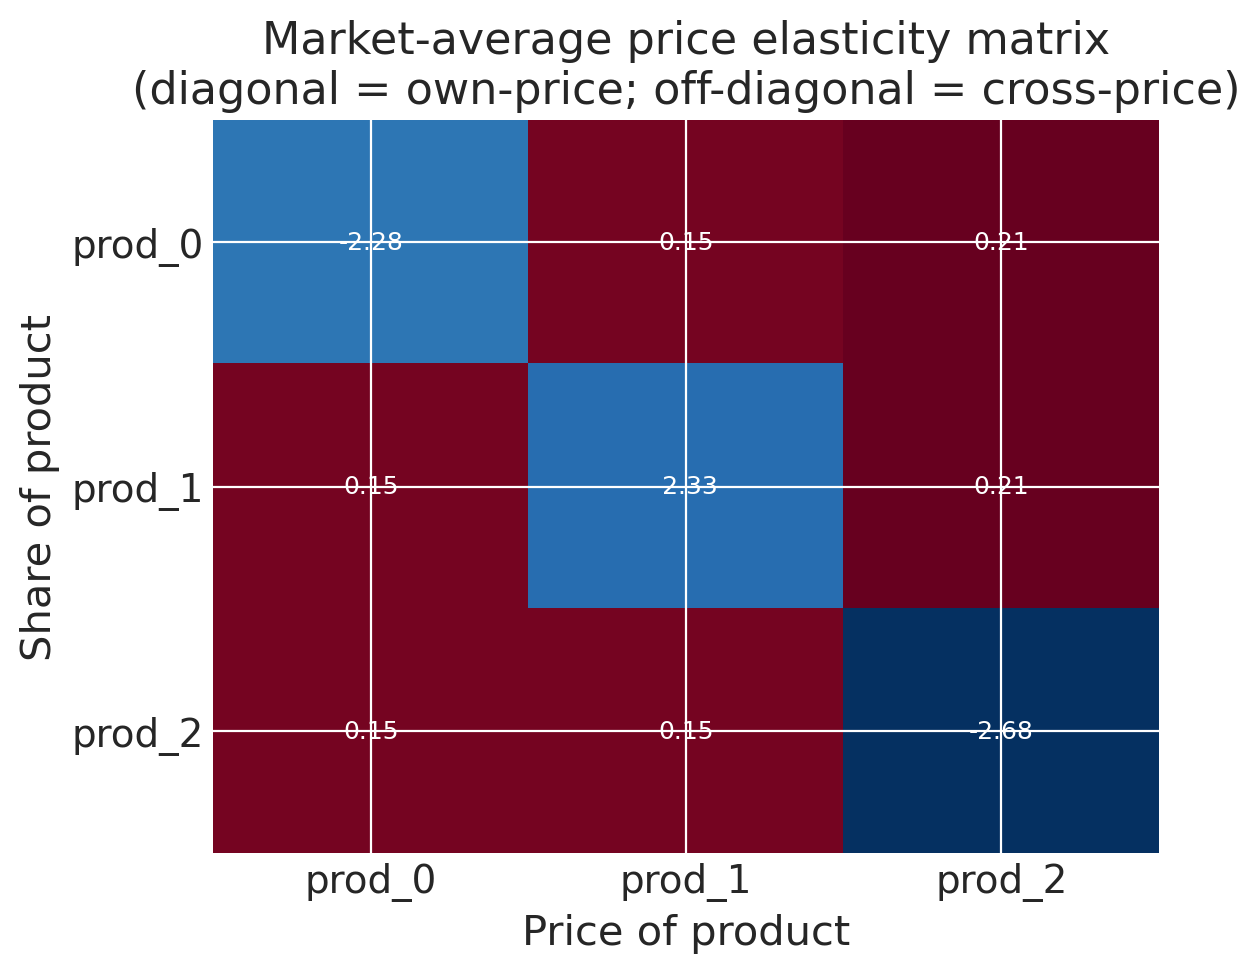

In [27]:
# Average across markets
elast_mean = elast.mean(dim="market").values  # (J, J)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(elast_mean, cmap="RdBu_r", aspect="auto")
# plt.colorbar(im, ax=ax, label='Elasticity')
ax.set_xticks(range(model._J))
ax.set_yticks(range(model._J))
ax.set_xticklabels(model._inside_products)
ax.set_yticklabels(model._inside_products)
ax.set_xlabel("Price of product")
ax.set_ylabel("Share of product")
ax.set_title(
    "Market-average price elasticity matrix\n"
    "(diagonal = own-price; off-diagonal = cross-price)"
)
for i in range(model._J):
    for j in range(model._J):
        ax.text(
            j,
            i,
            f"{elast_mean[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            color="white",
        )
plt.tight_layout()
plt.show()

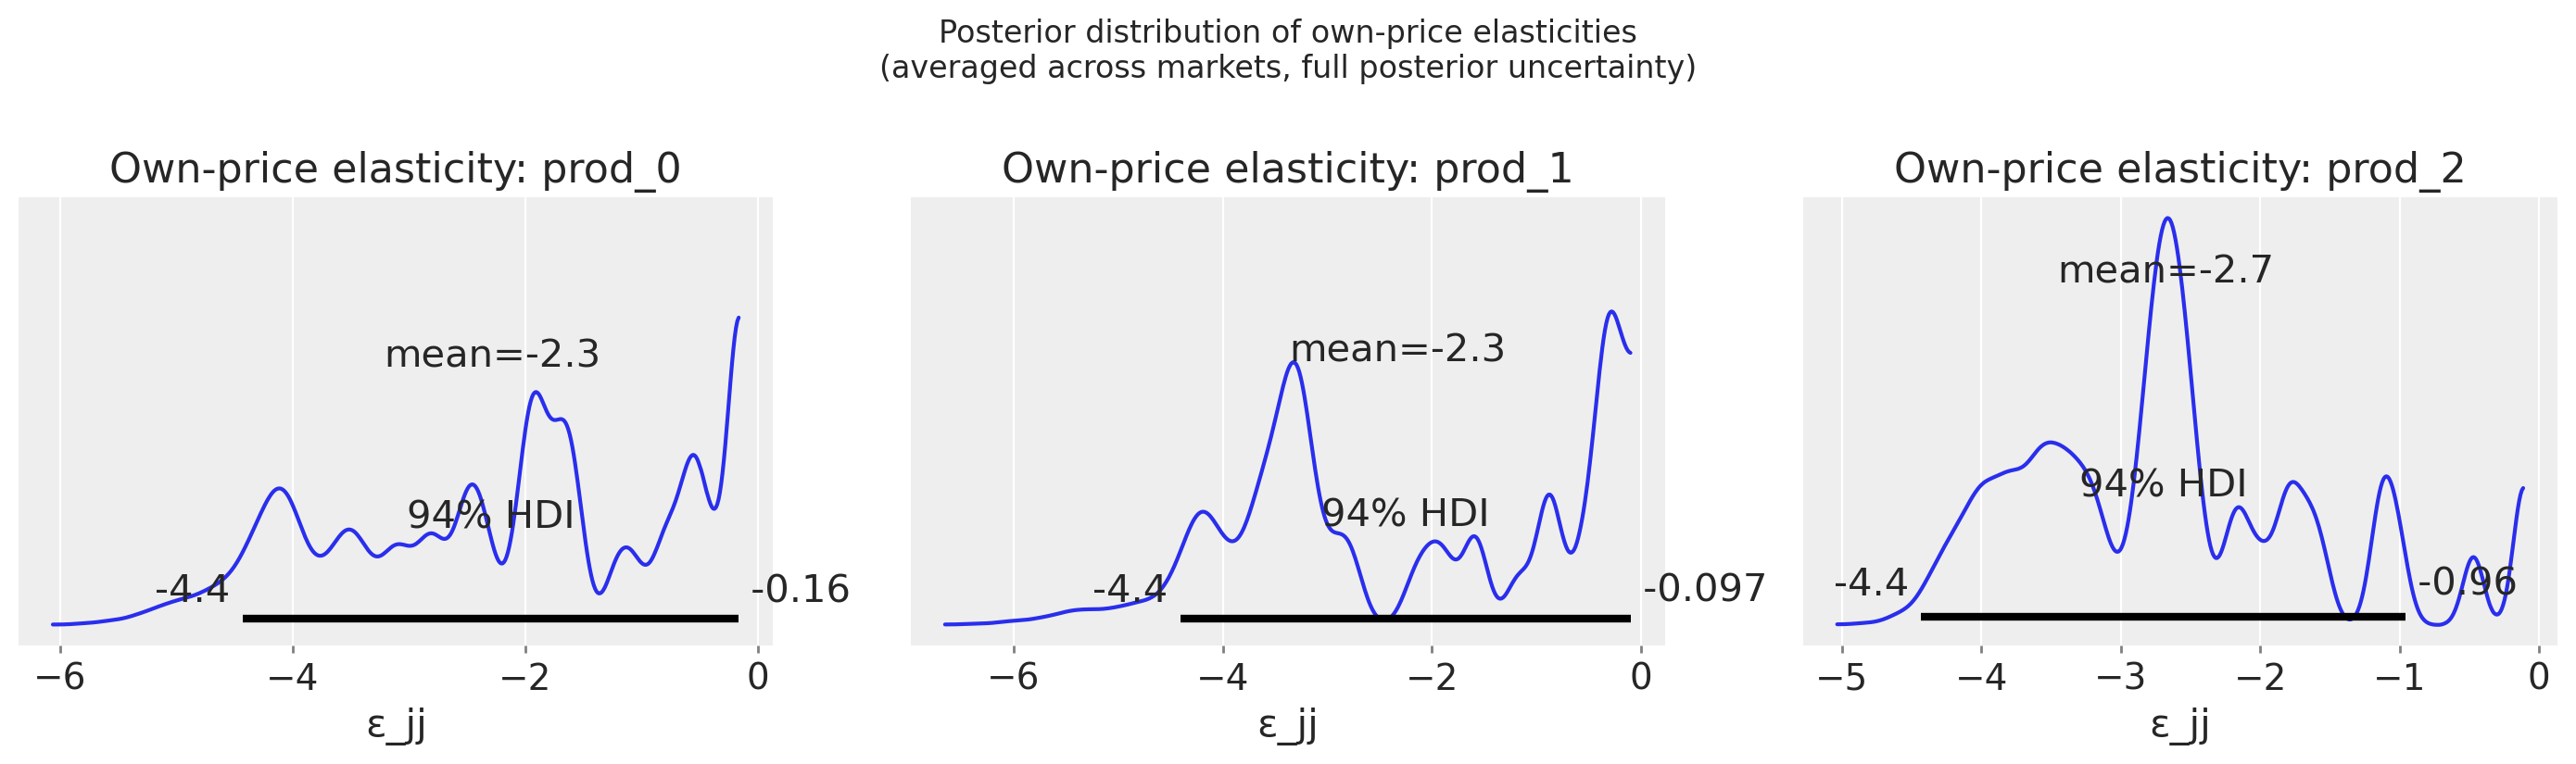

In [ ]:
# Posterior distribution of own-price elasticity for the first product
elast_samples = model.elasticities(at="samples", n_samples=300)

fig, axs = plt.subplots(1, model._J, figsize=(14, 4), sharey=True)
for j, (ax, pname) in enumerate(zip(axs, model._inside_products, strict=True)):
    own_samples = elast_samples.values[:, :, j, j].ravel()  # sample by market
    az.plot_posterior({"own_ε": own_samples}, var_names=["own_ε"], ax=ax)
    ax.set_title(f"Own-price elasticity: {pname}")
    ax.set_xlabel("ε_jj")

plt.suptitle(
    "Posterior distribution of own-price elasticities\n"
    "(averaged across markets, full posterior uncertainty)",
    y=1.02,
)
plt.tight_layout()
plt.show()

## 7. Counterfactual pricing

`counterfactual_shares(price_change=...)` holds the latent demand shock ξ_jt
constant (read directly from the posterior) and re-evaluates the share equation
at new prices. This is the structurally correct counterfactual: it asks *given
the same unobserved market conditions*, what would market shares be at the new
prices?

We examine a **10 % price hike on the first product**:
- its own share should fall (consumers substitute away)
- rival shares and the outside good should rise


In [29]:
target_product = model._inside_products[0]
print(f"Applying 10% price hike to: {target_product}")

baseline_cf = model.counterfactual_shares(price_change=None, n_samples=300)
shocked_cf = model.counterfactual_shares(
    price_change={target_product: 0.10}, n_samples=300
)

baseline_s = baseline_cf["s_inside"].mean(dim="sample").values  # (M, J)
shocked_s = shocked_cf["s_inside"].mean(dim="sample").values
delta_s = shocked_s - baseline_s  # share change

baseline_s_out = baseline_cf["s_outside"].mean(dim="sample").values  # (M,)
shocked_s_out = shocked_cf["s_outside"].mean(dim="sample").values

print("\nMarket-average share changes after 10% price hike on", target_product)
print("-" * 55)
for j, pname in enumerate(model._inside_products):
    b = baseline_s[:, j].mean()
    s = shocked_s[:, j].mean()
    print(f"  {pname:<12}  baseline={b:.4f}  shocked={s:.4f}  Δ={s - b:+.4f}")
print(
    f"  {'outside':<12}  baseline={baseline_s_out.mean():.4f}  "
    f"shocked={shocked_s_out.mean():.4f}  "
    f"Δ={shocked_s_out.mean() - baseline_s_out.mean():+.4f}"
)

Applying 10% price hike to: prod_0

Market-average share changes after 10% price hike on prod_0
-------------------------------------------------------
  prod_0        baseline=0.1066  shocked=0.0961  Δ=-0.0105
  prod_1        baseline=0.1419  shocked=0.1432  Δ=+0.0013
  prod_2        baseline=0.0851  shocked=0.0861  Δ=+0.0011
  outside       baseline=0.6665  shocked=0.6746  Δ=+0.0081


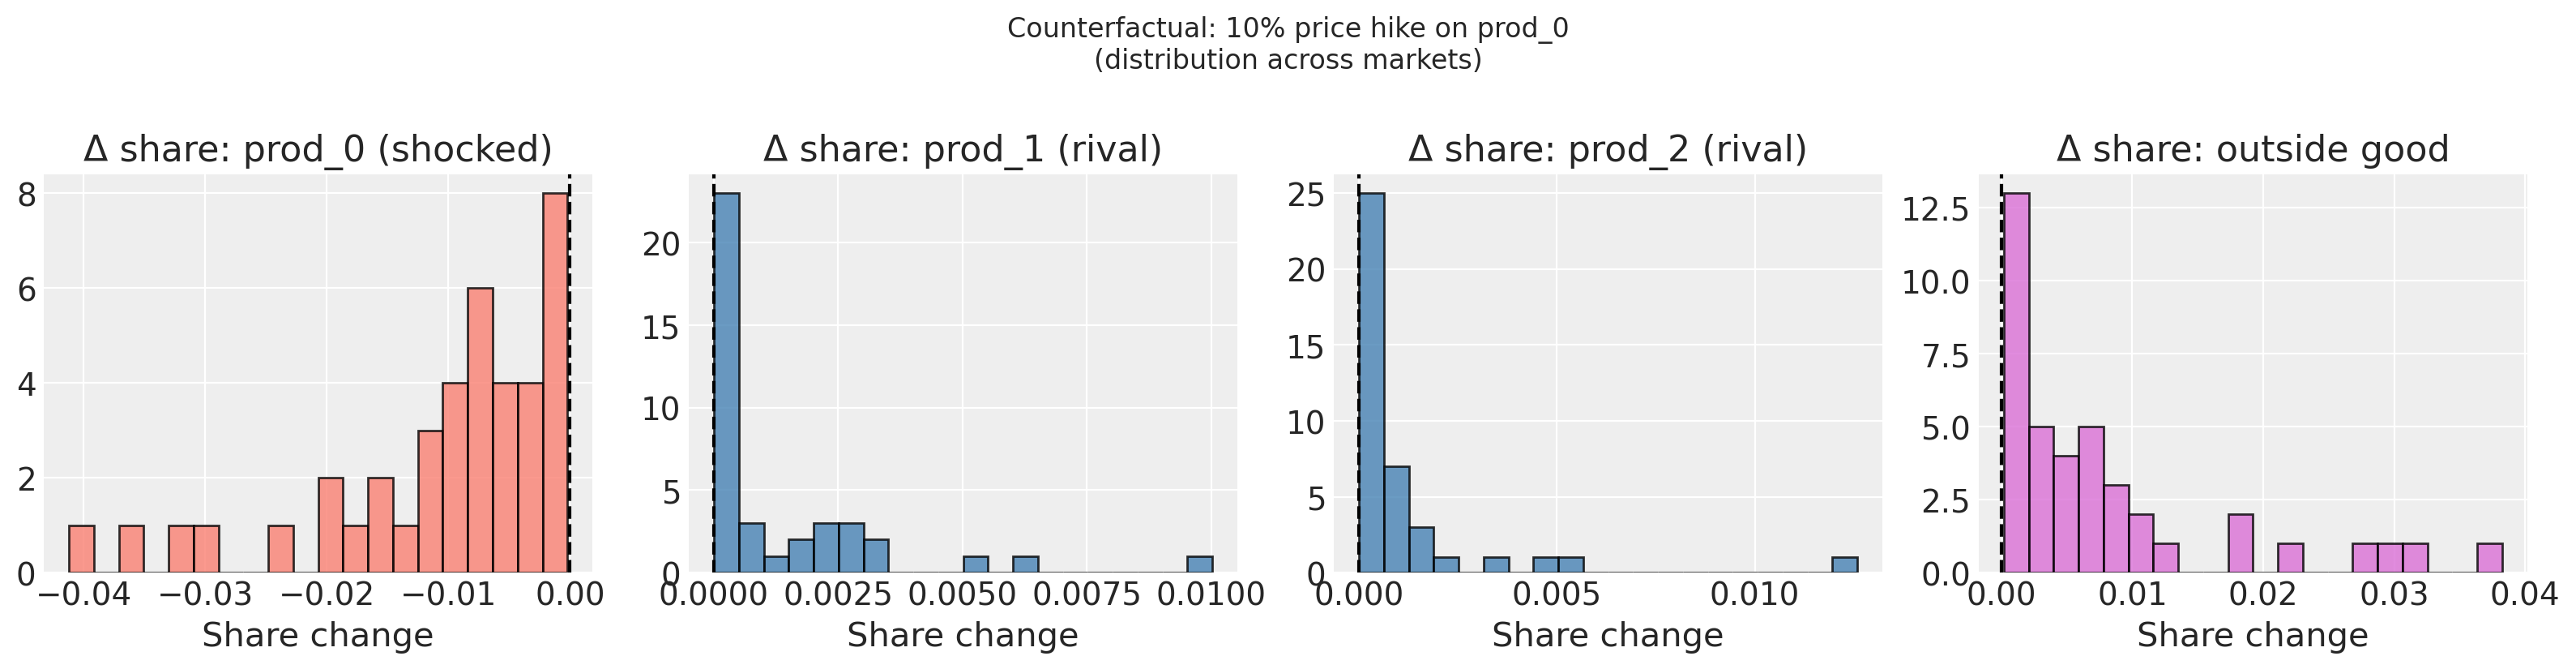

In [ ]:
# Visualise share-change distributions across markets
fig, axs = plt.subplots(1, model._J + 1, figsize=(16, 4))

for j, (ax, pname) in enumerate(zip(axs[:-1], model._inside_products, strict=True)):
    colour = "salmon" if pname == target_product else "steelblue"
    ax.hist(delta_s[:, j], bins=20, color=colour, alpha=0.8, edgecolor="k")
    ax.axvline(0, color="k", lw=1.5, ls="--")
    ax.set_title(
        f"Δ share: {pname}" + (" (shocked)" if pname == target_product else " (rival)")
    )
    ax.set_xlabel("Share change")

delta_out = shocked_s_out - baseline_s_out
axs[-1].hist(delta_out, bins=20, color="orchid", alpha=0.8, edgecolor="k")
axs[-1].axvline(0, color="k", lw=1.5, ls="--")
axs[-1].set_title("Δ share: outside good")
axs[-1].set_xlabel("Share change")

plt.suptitle(
    f"Counterfactual: 10% price hike on {target_product}\n"
    "(distribution across markets)",
    y=1.02,
)
plt.tight_layout()
plt.show()

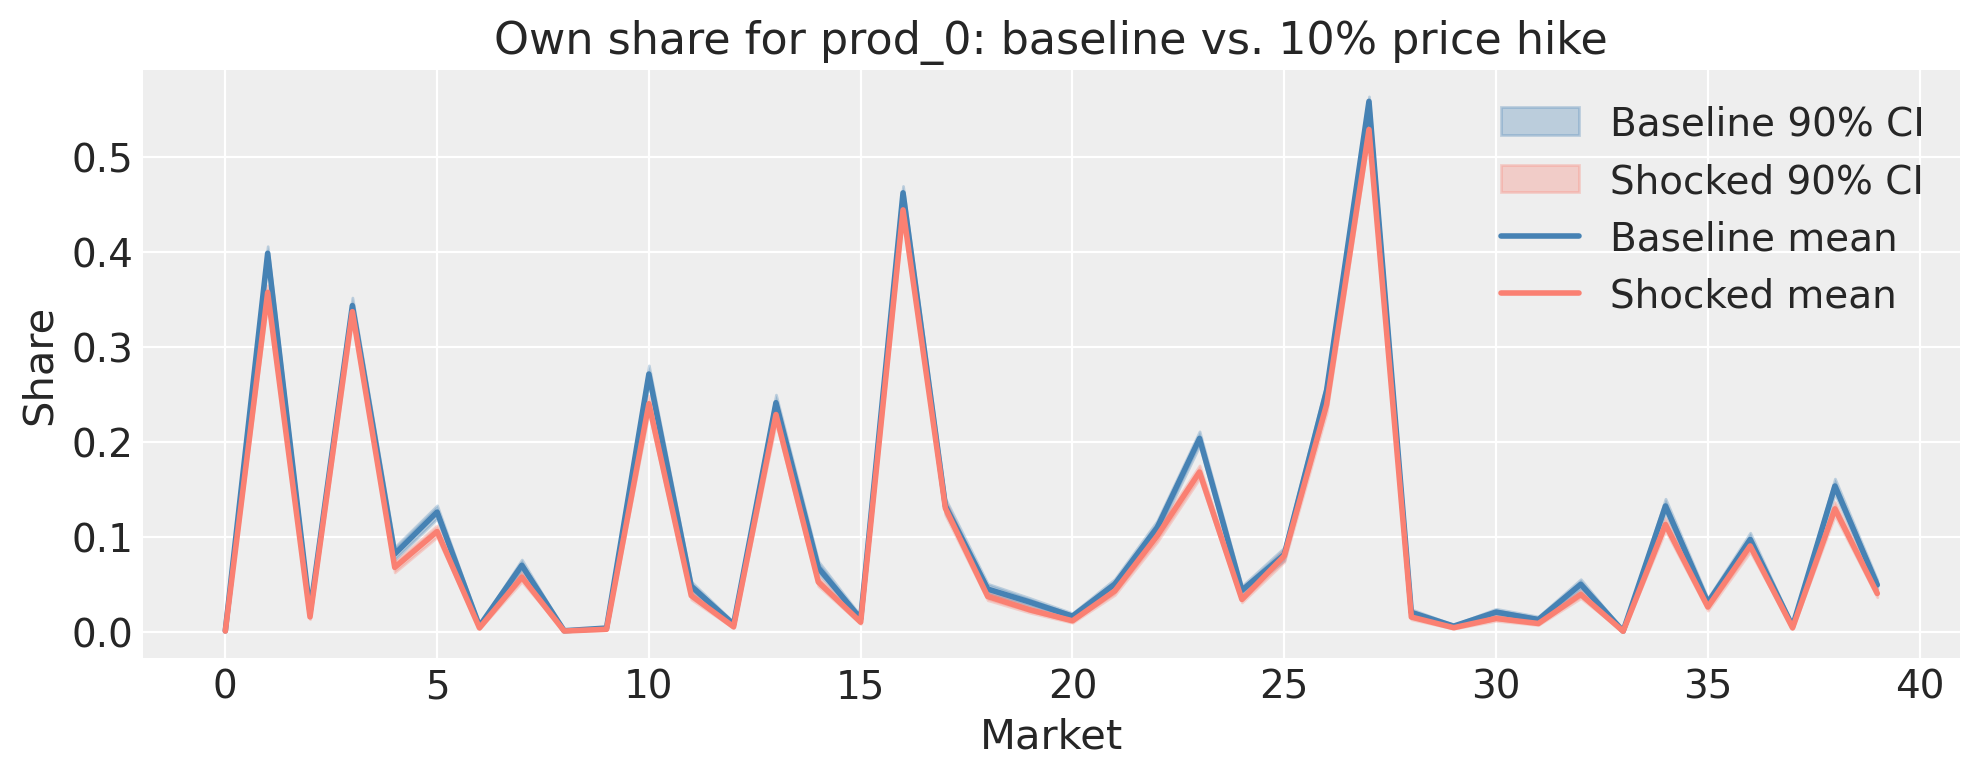

In [31]:
# Uncertainty fan: posterior distribution over counterfactual own share
own_idx = model._inside_products.index(target_product)
base_own_samples = baseline_cf["s_inside"].values[:, :, own_idx]  # (S, M)
shock_own_samples = shocked_cf["s_inside"].values[:, :, own_idx]  # (S, M)

fig, ax = plt.subplots(figsize=(10, 4))

lo_b, hi_b = np.quantile(base_own_samples, [0.05, 0.95], axis=0)
lo_s, hi_s = np.quantile(shock_own_samples, [0.05, 0.95], axis=0)
markets_x = range(model._M)

ax.fill_between(
    markets_x, lo_b, hi_b, alpha=0.3, color="steelblue", label="Baseline 90% CI"
)
ax.fill_between(
    markets_x, lo_s, hi_s, alpha=0.3, color="salmon", label="Shocked 90% CI"
)
ax.plot(base_own_samples.mean(axis=0), color="steelblue", lw=2, label="Baseline mean")
ax.plot(shock_own_samples.mean(axis=0), color="salmon", lw=2, label="Shocked mean")
ax.set_xlabel("Market")
ax.set_ylabel("Share")
ax.set_title(f"Own share for {target_product}: baseline vs. 10% price hike")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Hierarchical pooling across regions

When markets belong to distinct geographic regions, `region_col` activates
partial pooling across regions:

```
α_pop ~ N(0, 2)    τ_α ~ HalfNormal(1)
α_r   = α_pop + τ_α · α_r_raw        α_r_raw ~ N(0, 1)
```

This is the headline differentiator vs GMM BLP: thin markets are shrunk
toward the population mean, giving stable inference without discarding data.

We generate a 3-region panel with genuine region-level preference heterogeneity
(`region_heterogeneity=0.6`) and verify that `τ_α` (the between-region SD)
has posterior mass away from zero.


In [32]:
df_multi, truth_multi = generate_blp_panel(
    T=20,
    J=3,
    K=2,
    L=2,
    R_geo=3,
    region_heterogeneity=0.6,
    true_alpha=-2.0,
    sigma_alpha=0.5,
    instrument_strength=0.7,
    price_xi_corr=0.5,
    market_size=4_000,
    n_dgp_draws=3_000,
    random_seed=7,
    return_truth=True,
)

print("Regions:", df_multi["region"].unique())
print("Markets per region:", df_multi.groupby("region")["market"].nunique().to_dict())
print("True per-region alpha_r:", np.round(truth_multi["alpha_r"], 3))

Regions: ['r0' 'r1' 'r2']
Markets per region: {'r0': 20, 'r1': 20, 'r2': 20}
True per-region alpha_r: [-1.999 -1.821 -2.164]


In [33]:
model_hier = BayesianBLP(
    market_data=df_multi,
    characteristics=truth_multi["characteristic_cols"],
    instruments=truth_multi["instrument_cols"],
    region_col="region",
    random_coef_on=["price"],
    n_mc_draws=100,
    random_seed=0,
)
model_hier.fit(**_FIT_KWARGS)
n_div_hier = int(model_hier.idata.sample_stats["diverging"].values.sum())
print(f"Divergences: {n_div_hier}")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.03,767
,2000,0,0.03,255
,2000,0,0.03,127
,2000,0,0.03,127


Divergences: 0


In [35]:
az.summary(
    model_hier.idata,
    var_names=["alpha_pop", "tau_alpha", "alpha_r"],
    round_to=2,
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_pop,-1.91,0.22,-2.34,-1.45,0.02,0.02,78.24,155.23,1.06
tau_alpha,0.36,0.26,0.08,0.83,0.02,0.02,123.65,314.84,1.03
alpha_r[r0],-1.95,0.06,-2.07,-1.84,0.00,0.00,240.48,555.43,1.03
alpha_r[r1],-1.78,0.06,-1.89,-1.67,0.00,0.00,181.84,616.63,1.03
alpha_r[r2],-2.09,0.06,-2.21,-1.98,0.01,0.00,146.28,507.35,1.04


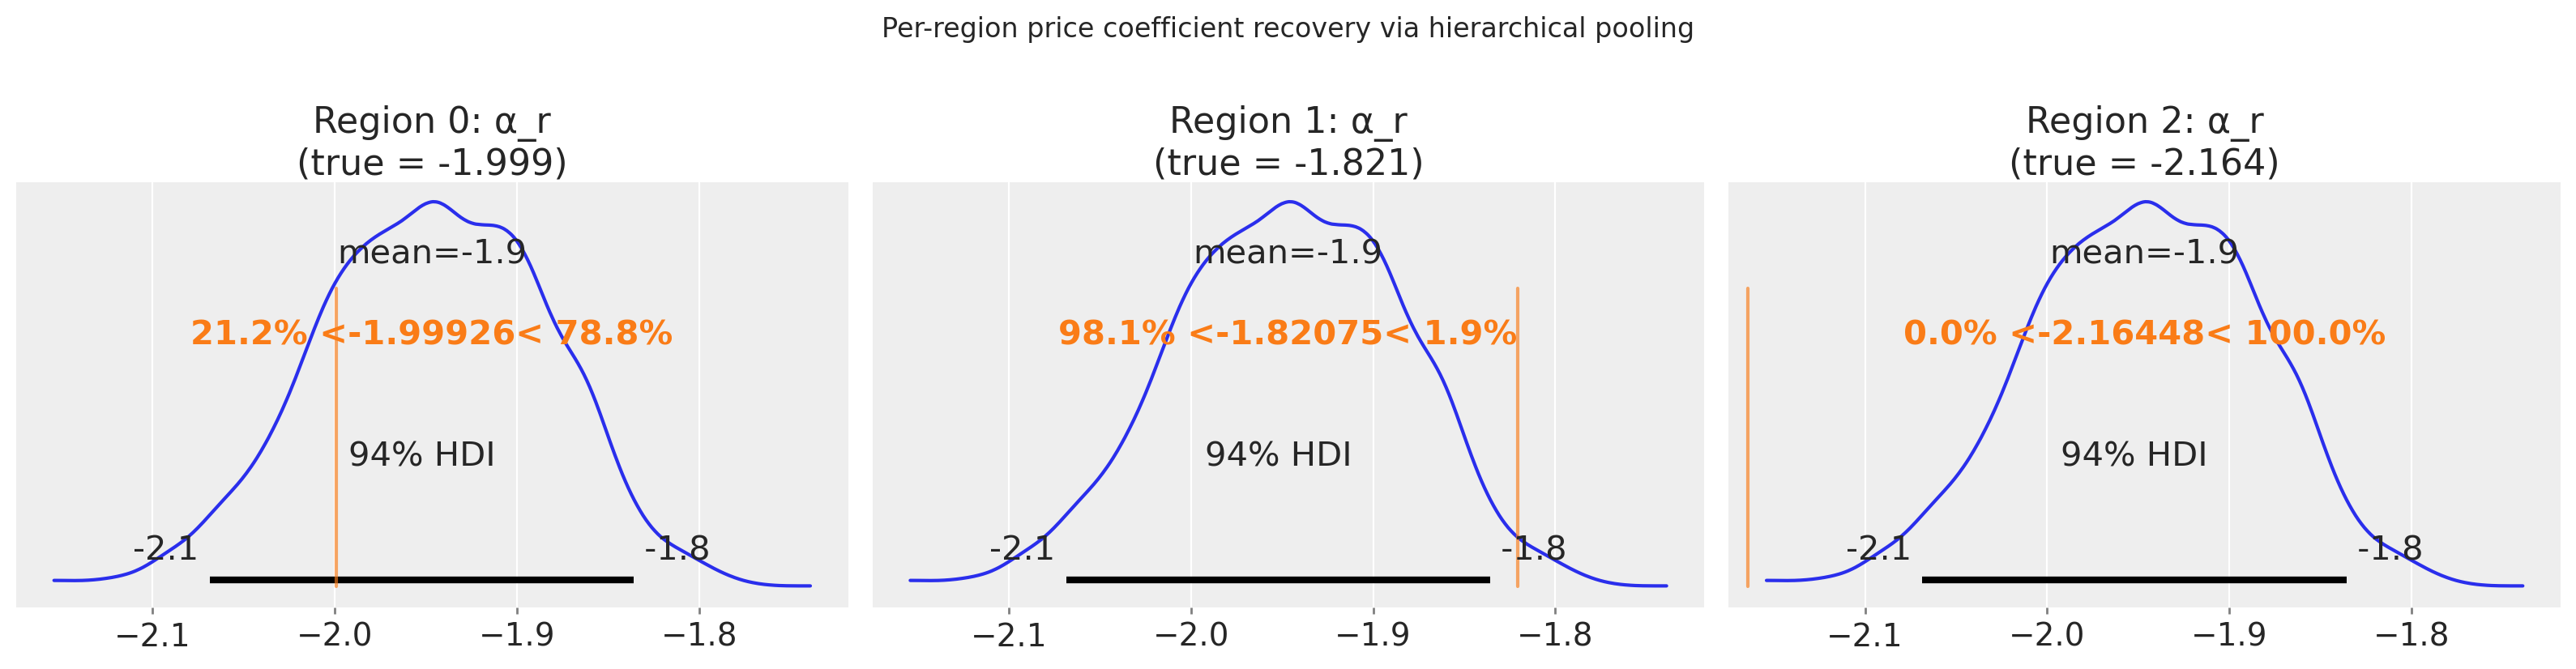

In [ ]:
# Region-level alpha recovery
fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

regions = truth_multi["alpha_r"]
for r, (ax, true_val) in enumerate(zip(axs, regions, strict=True)):
    az.plot_posterior(
        model_hier.idata,
        var_names=["alpha_r"],
        # coords={'region': r},
        ref_val=float(true_val),
        ax=ax,
    )
    ax.set_title(f"Region {r}: α_r\n(true = {true_val:.3f})")

plt.suptitle("Per-region price coefficient recovery via hierarchical pooling", y=1.02)
plt.tight_layout()
plt.show()

In [38]:
# tau_alpha: between-region SD should be > 0 under genuine heterogeneity
tau_lo, tau_hi = az.hdi(
    model_hier.idata.posterior["tau_alpha"].values.ravel(), hdi_prob=0.94
)
print(f"tau_alpha 94% HDI: [{tau_lo:.3f}, {tau_hi:.3f}]")
print("tau_alpha lower bound > 0:", tau_lo > 0)

tau_alpha 94% HDI: [0.083, 0.832]
tau_alpha lower bound > 0: True


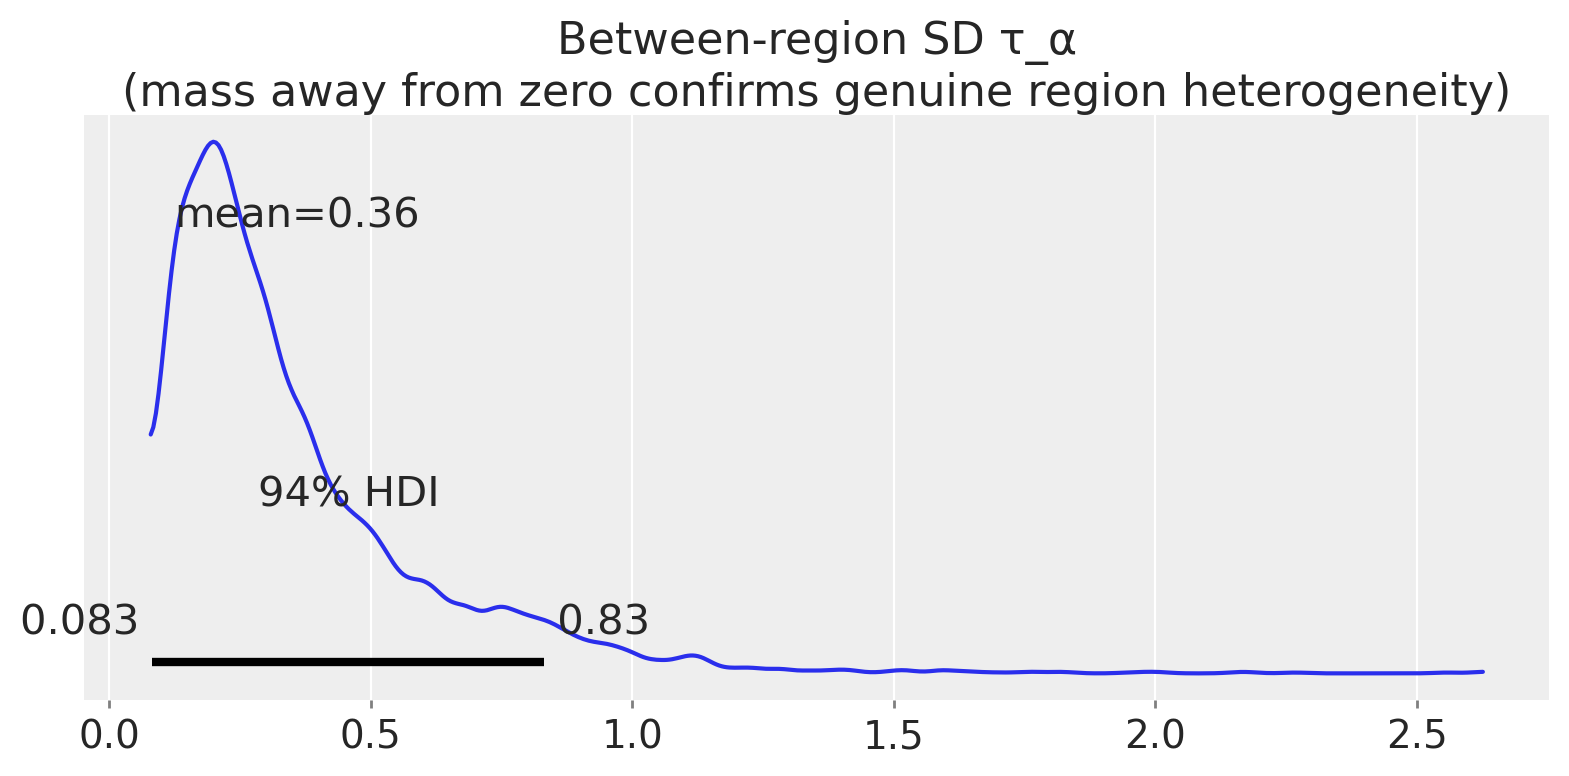

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
az.plot_posterior(model_hier.idata, var_names=["tau_alpha"], ax=ax)
ax.set_title(
    "Between-region SD τ_α\n(mass away from zero confirms genuine region heterogeneity)"
)
plt.tight_layout()
plt.show()

## 9. Model interpretation and structural story

### What the model estimates

- **`alpha_r`** — the mean price coefficient in region `r`. Because prices are
  endogenous (firms observe ξ before setting prices), naive OLS on shares would
  absorb the price–ξ correlation into `alpha`, biasing it toward zero. The joint
  model with instruments removes this bias through the conditional decomposition
  `ξ̃ | η ~ N(ρ · σ_ξ/σ_η · η, σ_ξ · √(1−ρ²))`.

- **`rho_price_xi`** — the endogeneity correlation ρ. A positive value (prices
  rise with positive demand shocks) is the standard finding in scanner data and
  confirms that instruments are doing work.

- **`sigma_random`** — consumer heterogeneity in price sensitivity. This drives
  the own-price elasticities away from the IIA logit value and produces a
  realistic cross-price substitution pattern.

- **`xi`** — the latent product-market demand shock. Markets where ξ_jt is high
  are those where product j was especially popular beyond what observables explain
  (a promotion, a competitor stockout, a viral moment). Monitoring the posterior
  mean of ξ over time can detect these events retrospectively.

### Counterfactual validity

The counterfactual holds ξ fixed at its posterior draw. This is the correct
semantic: we are asking *under the same unobserved market conditions*, what would
shares be at new prices? It is not a causal claim about what would happen if a
firm actually changed prices (that would require a supply-side equilibrium model),
but it is the standard in structural demand estimation and is much more credible
than a reduced-form share regression.

### Caveats

- The outside-good definition matters: `market_size` (the category volume that
  determines the outside share) affects every elasticity. Sensitivity analysis
  over `market_size` is recommended.
- Weak instruments inflate posterior credible intervals on `alpha` (Bayesian
  inference stays honest) but also inflate elasticity uncertainty.
- The supply side is not modelled (v1). For merger simulation or optimal pricing,
  a Bertrand-Nash markup equation should be appended.


## 10. Summary

In this notebook we demonstrated the full BayesianBLP workflow:

1. **Data generation** — `generate_blp_panel` with endogenous prices and known truth.
2. **Prior predictive check** — shares sum to 1; priors cover plausible scanner data.
3. **IV fit** — zero divergences; posterior recovers `α`, `β`, `σ_α` inside the 94% HDI.
4. **Endogeneity bias** — dropping instruments biases `α` toward zero by `≈0.16`;
   instruments correct this.
5. **Elasticities** — own-price negative (−3 to −5 range); cross-price positive;
   full posterior uncertainty available.
6. **Counterfactual** — a 10% price hike on one product reduces its share,
   raises rivals and the outside good, with calibrated posterior uncertainty.
7. **Hierarchical pooling** — `τ_α > 0` confirms genuine region heterogeneity;
   per-region `α_r` recovers truth via partial pooling.


In [ ]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing